# Running BoaMotion

BoaMotion measures how strongly and how quickly a piece of muscle contracts, from a
recording of it beating under a microscope. It needs no markers and no segmentation:
it compares every frame against a still one and turns the difference into a trace.

This page runs a whole analysis end to end. It uses a generated recording so that it
runs anywhere, but nothing about the steps changes when the frames come from a
microscope. If BoaMotion is not installed yet, see the installation page first.

## A recording to work with

`synthetic_recording()` builds a small beating recording whose peaks are known exactly,
which makes it useful for trying things out.

In [1]:
%matplotlib inline

from boamotion import Boa, synthetic_recording

rec = synthetic_recording(noise=0.01)
rec.frames.shape, rec.framerate

((100, 64, 80), 25.0)

Four beats over a hundred 64x80 frames, at 25 frames per second.

For your own data, hand `Boa` the folder your frames are in instead, and it reads the
TIFFs in order:

```python
boa = Boa("recordings/A001", framerate=25)
```

Anything that yields two-dimensional frames works too, which is what we use here.

On a real recording nothing changes but the numbers — more frames, more beats, and
no need to lower `peak_window` the way this short one does.

## Settings

Only the framerate really has to be set, since it turns frame counts into milliseconds
and nothing in the file can tell BoaMotion what it was. Everything else has a default
taken from the original MUSCLEMOTION macro.

Here, we also lower `peak_window`. It is how many frames the beat detector looks across,
and the default of 20 is wider than this short recording can afford at its far end.

In [2]:
boa = Boa(rec.frames, name="demo", framerate=rec.framerate, peak_window=16)

`boa.params.to_dict()` shows every setting and what it is currently at. They can equally be
changed after construction with `boa.set_params(...)`.

## Running

`run()` works through the four stages — choosing a reference frame, building a pixel
mask, measuring the contraction and speed traces, then finding and measuring each
beat — and hands back everything it found.

In [3]:
res = boa.run()
res

Result('demo': 99 points, reference frame 52, 4 beats, masked)

A run reports anything it could not do as warnings rather than failing quietly,
so it is worth reading those before the numbers.

In [4]:
for warning in res.warnings:
    print(warning)

ref_search_stop reduced from 300 to 97: the recording has 100 frames
No crossing on the falling flank of beat 4; its durations are left empty


Both warnings here are consequences of the recording being only a hundred frames long:
the search for a reference frame is capped at the frames that exist, and the last beat
runs off the end of the trace before it has fully relaxed, so its durations stay empty.

## The results

One row per beat, with the amplitudes, the time to peak, the relaxation time and the
transient durations. What each column means is described in the method page.

In [5]:
res.beats

,peak_position,peak_time_ms,baseline,peak_amplitude,contraction_amplitude,time_to_peak_ms,relaxation_time_ms,contraction_duration_ms,peak_to_peak_ms,transient_10pct_ms,transient_50pct_ms,transient_90pct_ms
beat,,,,,,,,,,,,
1,15,600.0,52.682812,1468.631445,1415.948633,200.0,280.0,480.0,NaN,480.0,320.0,160.0
2,40,1600.0,52.788672,1464.498633,1411.709961,200.0,280.0,480.0,1000.0,480.0,320.0,160.0
3,64,2560.0,52.947852,1465.271094,1412.323242,200.0,280.0,480.0,960.0,480.0,320.0,160.0
4,89,3560.0,53.695703,1467.878320,1414.182617,200.0,NaN,NaN,1000.0,NaN,NaN,NaN


The contraction trace. A red line marks each detected peak, running down to the baseline
that beat was measured from:

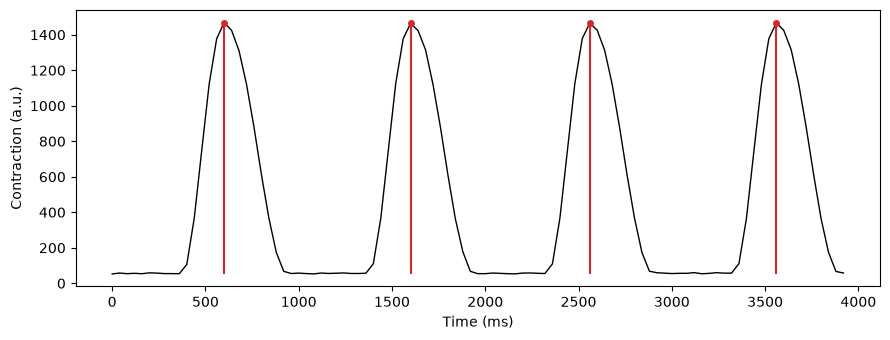

In [6]:
res.plot_contraction()

`res.plot_speed()` and `res.plot_speed_comparison()` show the speed of contraction
the same way.

## Saving

`save()` writes the traces, the table, the figures and a log into a new folder, and
returns the folder path it actually used. An existing one is never overwritten.

In [7]:
import tempfile
from pathlib import Path

folder = res.save(tempfile.mkdtemp())
sorted(path.name for path in Path(folder).iterdir())

['beats.csv',
 'contraction.png',
 'contraction.txt',
 'log.txt',
 'overview-results.txt',
 'parameters.yaml',
 'run-summary.txt',
 'speed-comparison.png',
 'speed-of-contraction.png',
 'speed-of-contraction.txt']

## Where to go next

- [What the analysis computes](how-it-works.md) — the method, and what each parameter
  changes.
- [The analysis stage by stage](../dev/BUILDING_BLOCKS.ipynb) — the same pipeline with
  each stage called on its own.